Generating Animation...


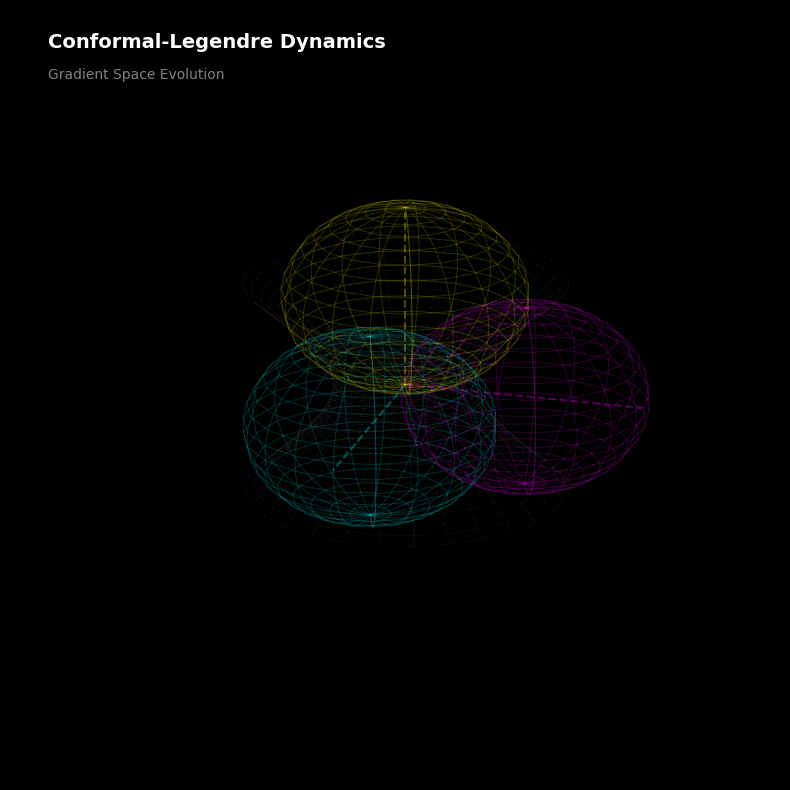

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource

# --- Configuration & Aesthetics ---
plt.style.use('dark_background')
FIG_SIZE = (10, 10)
DPI = 100
FRAMES = 120
FPS = 20

# Neon Color Palette for the 3 Potentials
COLORS = [
    (0.0, 1.0, 1.0), # Cyan (Potential 1)
    (1.0, 0.0, 1.0), # Magenta (Potential 2)
    (1.0, 1.0, 0.0)  # Yellow (Potential 3)
]

def householder_update(y, target_u, lr=0.05):
    """
    Simulates the Conformal-Wasserstein Gradient Flow update.
    
    Math:
    v = y / |y|^2  (Kelvin Transform/Traversal)
    J = (1/|y|^2) * (I - 2*u*u.T)  (Jacobian/Householder)
    dy = J * (target_u - v)
    """
    norm_sq = np.dot(y, y)
    if norm_sq < 1e-6: # Regularization for 0
        norm_sq = 1e-6
        
    # The current traversal vector
    v = y / norm_sq
    
    # The Normalized Gradient Direction
    u_hat = y / np.sqrt(norm_sq)
    
    # Householder Matrix H = I - 2uu^T
    H = np.eye(3) - 2 * np.outer(u_hat, u_hat)
    
    # The Force from the Recognizer (Pulling traversal v towards target u*)
    force = target_u - v
    
    # The Conformal Jacobian adjustment
    dy = (1.0 / norm_sq) * (H @ force)
    
    # Update with geometric dampening (simulating the edge of chaos friction)
    return y + lr * dy

def generate_sphere_mesh(center, radius, resolution=20):
    """Generates coordinates for a 3D sphere."""
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

def generate_hyperboloid_mesh(a=1, b=1, c=1, resolution=30):
    """Generates a 1-sheet hyperboloid representing the manifold curvature."""
    u = np.linspace(-2, 2, resolution)
    v = np.linspace(0, 2 * np.pi, resolution)
    u, v = np.meshgrid(u, v)
    
    x = a * np.sqrt(1 + u**2) * np.cos(v)
    y = b * np.sqrt(1 + u**2) * np.sin(v)
    z = c * u
    return x, y, z

# --- Initialization ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')
ax.set_axis_off() # Clean look

# Initial states for the 3 potentials (slightly perturbed from origin)
# Positions in Gradient Space
particles = [np.random.randn(3) * 0.01 + np.array([0.01, 0.01, 0.01]) for _ in range(3)]
trails = [[p.copy()] for p in particles]

# The "True" Semantic Directions (Target Fibers)
# They will rotate over time to show robustness
base_targets = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0])
]

# --- Animation Loop ---

def update(frame):
    ax.clear()
    ax.set_axis_off()
    
    # Rotation of the camera
    ax.view_init(elev=20, azim=frame * (360/FRAMES))
    
    # Time-varying rotation of the target semantics (The Manifold evolves)
    theta = frame * 0.05
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])
    
    current_targets = [rotation_matrix @ t for t in base_targets]
    
    # --- Draw The Geometric Objects ---
    
    # 1. The Hyperboloid (Background Manifold)
    # Pulsating scale
    scale = 0.5 + 0.1 * np.sin(frame * 0.1)
    hx, hy, hz = generate_hyperboloid_mesh(scale, scale, scale)
    ax.plot_wireframe(hx, hy, hz, color='white', alpha=0.05, linewidth=0.5)

    # 2. The Conformal Spheres (Acceptance Regions) & Particles
    for i in range(3):
        target = current_targets[i] * 1.5 # Scale target distance
        
        # The Acceptance Region in Gradient Space is a Sphere 
        # defined by ||y - target/2|| <= ||target/2||
        sphere_center = target / 2
        sphere_radius = np.linalg.norm(target) / 2
        
        sx, sy, sz = generate_sphere_mesh(sphere_center, sphere_radius)
        
        # Plot Sphere
        ax.plot_wireframe(sx, sy, sz, color=COLORS[i], alpha=0.15, linewidth=0.8)
        
        # Update Particle Physics (The Training Step)
        # The particle 'learns' to move into the sphere
        particles[i] = householder_update(particles[i], target, lr=0.02)
        trails[i].append(particles[i].copy())
        if len(trails[i]) > 20: trails[i].pop(0)
        
        # Draw Particle Trail
        t_arr = np.array(trails[i])
        ax.plot(t_arr[:,0], t_arr[:,1], t_arr[:,2], color=COLORS[i], linewidth=2, alpha=0.8)
        
        # Draw Particle Head
        ax.scatter([particles[i][0]], [particles[i][1]], [particles[i][2]], 
                   color='white', s=50, edgecolors=COLORS[i], linewidth=2)
        
        # Draw vector to center of sphere (The "Target" vector in Primal Space)
        ax.plot([0, target[0]], [0, target[1]], [0, target[2]], 
                color=COLORS[i], linestyle='--', alpha=0.3)

    # Limits
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_zlim(-1.5, 1.5)
    
    # Title
    ax.text2D(0.05, 0.95, "Conformal-Legendre Dynamics", transform=ax.transAxes, 
              color='white', fontsize=14, fontweight='bold')
    ax.text2D(0.05, 0.91, "Gradient Space Evolution", transform=ax.transAxes, 
              color='gray', fontsize=10)

# --- Generate and Save ---
# Note: To save as GIF, requires 'pillow' or 'imagemagick' installed.
print("Generating Animation...")
ani = animation.FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS)

# Save command (Uncomment to save file locally)
ani.save('conformal_dynamics.gif', writer='pillow', fps=FPS)

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# --- Visual Configuration ---
plt.style.use('dark_background')
FIG_SIZE = (10, 8)
DPI = 100
FRAMES = 120
FPS = 24

# Colors
COLOR_BALL = '#777777'  # Neutral Gray
COLOR_X = '#00FFFF'     # Cyan (Neon)
COLOR_Y = '#FF00FF'     # Magenta (Neon)
COLOR_Z = '#FFFF00'     # Yellow (Neon)
ALPHA_SURFACE = 0.3
ALPHA_WIRE = 0.1

def generate_ellipsoid(rx, ry, rz, res=30):
    """Generates a deformed sphere (Ellipsoid) representing the Conformal Ball."""
    u = np.linspace(0, 2 * np.pi, res)
    v = np.linspace(0, np.pi, res)
    x = rx * np.outer(np.cos(u), np.sin(v))
    y = ry * np.outer(np.sin(u), np.sin(v))
    z = rz * np.outer(np.ones_like(u), np.cos(v))
    return x, y, z

def generate_hyperboloid_sheet(axis, offset, opening=0.5, res=20, limit=2.0):
    """
    Generates a single sheet of a hyperboloid opening along a specific axis.
    Equation: axis^2 - (other^2 + other^2) = offset^2
    """
    # Grid for the transverse coordinates
    u = np.linspace(-limit, limit, res)
    v = np.linspace(-limit, limit, res)
    U, V = np.meshgrid(u, v)
    
    # Calculate the axial coordinate based on hyperboloid equation
    # x^2 - (y^2 + z^2) = k  =>  x = sqrt(k + y^2 + z^2)
    
    # Ensure we are "outside" the vertex
    # We model the acceptance region: Signal > Noise + Offset
    R2 = U**2 + V**2
    # We add a small epsilon to offset to prevent sqrt(negative) during transient overlap
    # though graphically we just shift the vertex.
    
    # The distance from origin to vertex is 'offset'
    # The shape is determined by 'opening'
    
    W = np.sqrt(offset**2 + opening * R2)
    
    if axis == 'x':
        return W, U, V
    elif axis == 'y':
        return U, W, V
    else: # axis == 'z'
        return U, V, W

def update_graph(frame):
    ax.clear()
    ax.set_axis_off()
    
    # --- Time Dynamics (0.0 to 1.0) ---
    # Smooth sigmoid easing for organic movement
    t = frame / FRAMES
    ease = 1 / (1 + np.exp(-10 * (t - 0.5))) # Sigmoid 
    
    # --- 1. The Conformal Ball Evolution ---
    # Starts small (0.2), expands to stabilization (1.0)
    # Evolving Geometry: Starts spherical, becomes slightly anisotropic (metric sharpening)
    base_r = 0.3 + 0.7 * ease
    
    # Slight contraction on non-principal axes to show "Metric Tension"
    # It breathes: Expand, then stabilize
    pulse = 1.0 + 0.05 * np.sin(t * np.pi * 4)
    
    bx, by, bz = generate_ellipsoid(base_r * pulse, base_r * pulse, base_r * pulse)
    ax.plot_surface(bx, by, bz, color=COLOR_BALL, alpha=0.6, 
                    rstride=2, cstride=2, linewidth=0, shade=True)
    
    # --- 2. The Recognizer Hyperboloids Evolution ---
    # Start far away (high offset), move inward to touch the ball
    # Start offset: 2.5
    # End offset: matches base_r (1.0) -> The "Kissing" Point
    
    offset_start = 2.5
    offset_end = 1.0 # Must match the max radius of the ball
    current_offset = offset_start - (offset_start - offset_end) * ease
    
    # Generate and Plot the 3 Hyperboloids
    
    # Axis X (Cyan)
    hx, hy, hz = generate_hyperboloid_sheet('x', current_offset)
    ax.plot_surface(hx, hy, hz, color=COLOR_X, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hx, hy, hz, color=COLOR_X, alpha=ALPHA_WIRE, rstride=5, cstride=5)
    
    # Axis Y (Magenta)
    hy_x, hy_y, hy_z = generate_hyperboloid_sheet('y', current_offset)
    ax.plot_surface(hy_x, hy_y, hy_z, color=COLOR_Y, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hy_x, hy_y, hy_z, color=COLOR_Y, alpha=ALPHA_WIRE, rstride=5, cstride=5)

    # Axis Z (Yellow)
    hz_x, hz_y, hz_z = generate_hyperboloid_sheet('z', current_offset)
    ax.plot_surface(hz_x, hz_y, hz_z, color=COLOR_Z, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hz_x, hz_y, hz_z, color=COLOR_Z, alpha=ALPHA_WIRE, rstride=5, cstride=5)
    
    # --- 3. Visual Polish ---
    
    # Camera Rotation
    ax.view_init(elev=25, azim=frame * (360 / FRAMES))
    
    # Limits
    limit = 2.2
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Annotations
    status = "Initializing..." if t < 0.2 else ("Stabilizing..." if t > 0.8 else "Evolving...")
    ax.text2D(0.05, 0.95, f"Conformal Metric Evolution", transform=ax.transAxes, 
              color='white', fontsize=14, fontweight='bold')
    ax.text2D(0.05, 0.90, f"Phase: {status}", transform=ax.transAxes, 
              color='gray', fontsize=10)

# --- Setup Figure ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')

print("Generating 3D Conformal Visualization...")
ani = animation.FuncAnimation(fig, update_graph, frames=FRAMES, interval=1000/FPS)

# Save
ani.save('conformal_equilibrium.gif', writer='pillow', fps=FPS)
plt.close()
print("Done. Saved as 'conformal_equilibrium.gif'")

Generating 3D Conformal Visualization...
Done. Saved as 'conformal_equilibrium.gif'


Rendering Volumetric Gaussian Visualization...
Done. Saved as 'gaussian_conformal_convergence.gif'


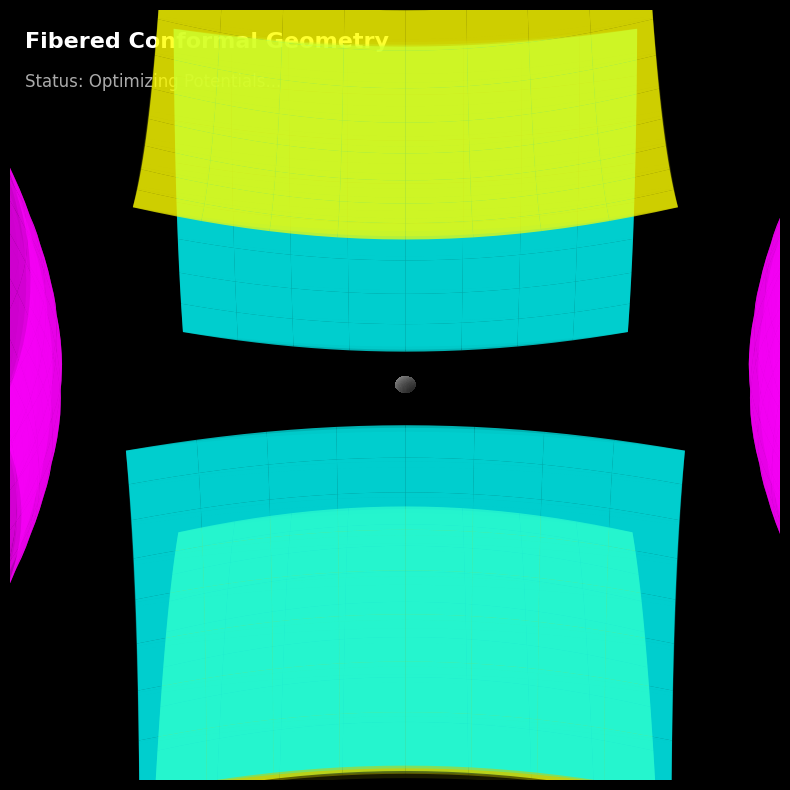

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# --- Configuration ---
plt.style.use('dark_background')
FIG_SIZE = (12, 10)
DPI = 100
FRAMES = 120
FPS = 24

# Neon Palette
COLOR_BALL = '#888888'   # Metric Gray
COLOR_X = '#00FFFF'      # Cyan
COLOR_Y = '#FF00FF'      # Magenta
COLOR_Z = '#FFFF00'      # Yellow

def get_ball_mesh(radius, res=40):
    """Generates a high-res smooth sphere mesh."""
    u = np.linspace(0, 2 * np.pi, res)
    v = np.linspace(0, np.pi, res)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

def get_hyperboloid_layers(axis, offset, bend_factor=0.6, res=25, limit=2.5):
    """
    Generates symmetric pairs of hyperboloids.
    Returns a list of (X, Y, Z, alpha) tuples representing 
    nested layers to simulate a volumetric Gaussian blur.
    """
    # Create the grid for the transverse axes
    u = np.linspace(-limit, limit, res)
    v = np.linspace(-limit, limit, res)
    U, V = np.meshgrid(u, v)
    
    # Radial distance squared in the transverse plane
    R2 = U**2 + V**2
    
    layers = []
    
    # We create 3 layers to simulate the Gaussian Core -> Blur
    # 1. Inner Core (Solid, Bright)
    # 2. Mid Glow (Semi-transparent)
    # 3. Outer Haze (Faint)
    
    # Definitions: (layer_offset_modifier, alpha, expansion_modifier)
    layer_defs = [
        (0.0,  0.7,  1.0),  # Core
        (0.1,  0.3,  1.1),  # Glow
        (0.25, 0.1,  1.3)   # Haze
    ]
    
    for mod, alpha, expand in layer_defs:
        # The shape equation: x = sqrt(offset^2 + bend * (y^2+z^2))
        # 'mod' shifts the layer slightly "back" into the acceptance region
        eff_offset = offset + mod 
        
        # 'expand' makes the blur wider
        W = np.sqrt(eff_offset**2 + (bend_factor / expand) * R2)
        
        # Create Positive Sheet
        if axis == 'x':
            layers.append((W, U, V, alpha))  # +X
            layers.append((-W, U, V, alpha)) # -X
        elif axis == 'y':
            layers.append((U, W, V, alpha))  # +Y
            layers.append((U, -W, V, alpha)) # -Y
        else: # z
            layers.append((U, V, W, alpha))  # +Z
            layers.append((U, V, -W, alpha)) # -Z
            
    return layers

def update(frame):
    ax.clear()
    ax.set_axis_off()
    
    # Time variable (0 to 1)
    t = frame / FRAMES
    
    # Easing functions
    # Ball expansion (starts fast, slows down)
    ease_ball = 1 - (1 - t)**3
    # Hyperboloid approach (starts slow, accelerates in, then stabilizes)
    ease_hyp = 1 / (1 + np.exp(-8 * (t - 0.6)))

    # --- 1. Conformal Ball Dynamics ---
    # Radius grows from 0.1 to 1.0
    r_current = 0.1 + 0.9 * ease_ball
    bx, by, bz = get_ball_mesh(r_current)
    
    # Plot Ball (Core)
    ax.plot_surface(bx, by, bz, color=COLOR_BALL, alpha=0.9, 
                    rstride=1, cstride=1, antialiased=False, shade=True)
    
    # --- 2. Hyperboloid Dynamics ---
    # Offset shrinks from 3.0 to 1.0 (The "Kissing Point")
    start_dist = 3.5
    end_dist = 1.0 # Matches max ball radius
    dist_current = start_dist - (start_dist - end_dist) * ease_hyp
    
    # --- 3. Plotting the Gaussian Splotches ---
    
    # Helper to plot a list of layers
    def plot_cloud(layers, color):
        for (X, Y, Z, a) in layers:
            ax.plot_surface(X, Y, Z, color=color, alpha=a, 
                           linewidth=0, shade=False, rstride=3, cstride=3)

    # X-Axis (Cyan)
    layers_x = get_hyperboloid_layers('x', dist_current)
    plot_cloud(layers_x, COLOR_X)
    
    # Y-Axis (Magenta)
    layers_y = get_hyperboloid_layers('y', dist_current)
    plot_cloud(layers_y, COLOR_Y)
    
    # Z-Axis (Yellow)
    layers_z = get_hyperboloid_layers('z', dist_current)
    plot_cloud(layers_z, COLOR_Z)
    
    # --- 4. Scene Setup ---
    limit = 2.5
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Camera Rotation
    ax.view_init(elev=30, azim=frame * (360 / FRAMES))
    
    # Labels
    status = "Manifold Stabilization" if t > 0.85 else "Optimizing Potentials..."
    ax.text2D(0.02, 0.95, "Fibered Conformal Geometry", transform=ax.transAxes,
              color='white', fontsize=16, fontweight='bold')
    ax.text2D(0.02, 0.90, f"Status: {status}", transform=ax.transAxes,
              color='#AAAAAA', fontsize=12)

# --- Main Execution ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')

# High quality pane color (make it disappear)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

print("Rendering Volumetric Gaussian Visualization...")
ani = animation.FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS)

ani.save('gaussian_conformal_convergence.gif', writer='pillow', fps=FPS)
print("Done. Saved as 'gaussian_conformal_convergence.gif'")

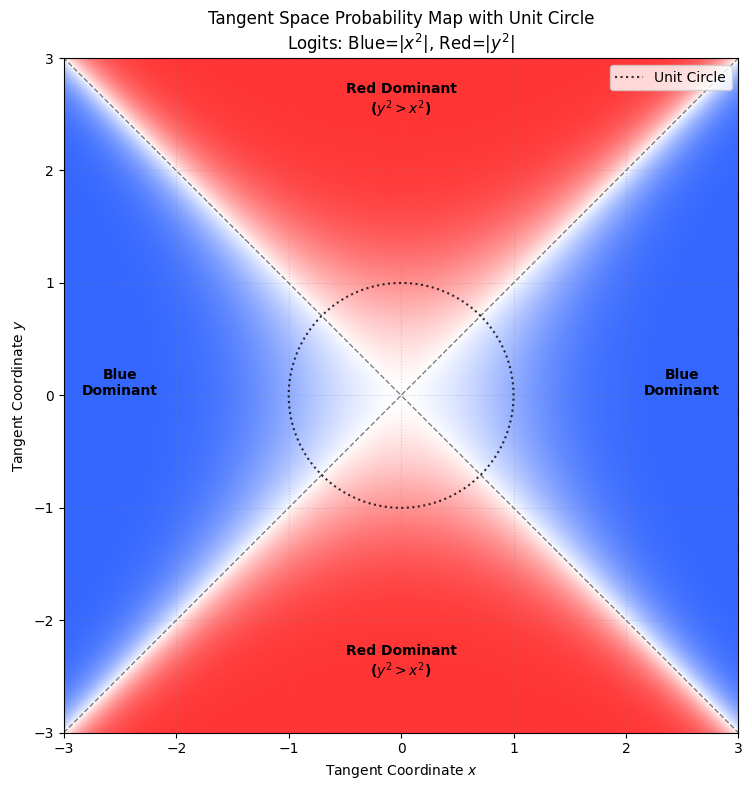

/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_43578/2526651695.py:14: RuntimeWarning: overflow encountered in exp
  exp_logits = np.exp(logits)
/opt/anaconda3/envs/manip311/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_43578/2526651695.py:16: RuntimeWarning: invalid value encountered in divide
  probs = exp_logits / sum_exp


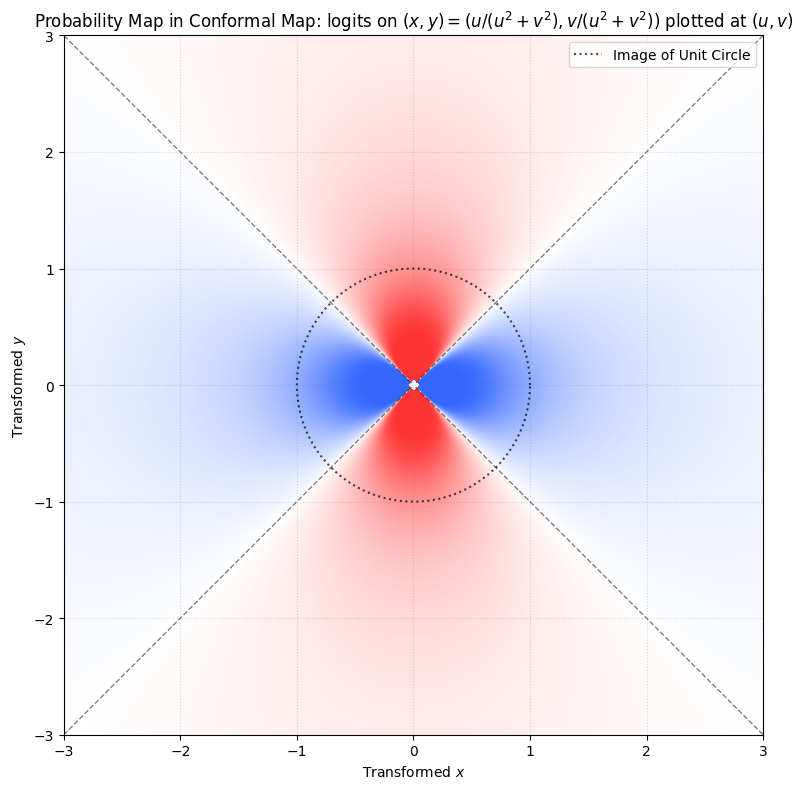

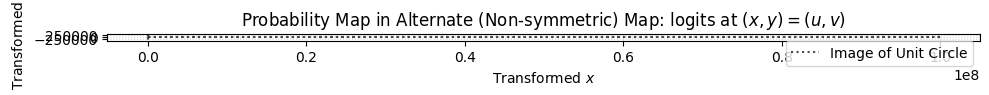

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_logits(X, Y):
    """Compute the logits for each class."""
    # Logit(blue) = |x^2|
    # Logit(red)  = |y^2|
    logit_blue = np.abs(X**2)
    logit_red  = np.abs(Y**2)
    return np.stack([logit_blue, logit_red], axis=-1)

def logits_to_rgba(logits, softmax_axis=-1):
    """Convert logits to an RGBA image and return probabilities for use."""
    exp_logits = np.exp(logits)
    sum_exp = np.sum(exp_logits, axis=softmax_axis, keepdims=True)
    probs = exp_logits / sum_exp

    prob_blue = probs[..., 0]
    prob_red  = probs[..., 1]

    # Build RGBA image
    rgba = np.zeros((*probs.shape[:-1], 4))
    blue_wins = prob_blue > prob_red

    # Blue: [0.2, 0.4, 1.0]
    rgba[blue_wins, 0] = 0.2
    rgba[blue_wins, 1] = 0.4
    rgba[blue_wins, 2] = 1.0

    # Red: [1.0, 0.2, 0.2]
    rgba[~blue_wins, 0] = 1.0
    rgba[~blue_wins, 1] = 0.2
    rgba[~blue_wins, 2] = 0.2

    confidence = np.max(probs, axis=softmax_axis)
    # Alpha: Map confidence in [0.5, 1.0] to [0, 1]
    alpha = (confidence - 0.5) * 2.0
    alpha = np.clip(alpha, 0, 1)
    # Optional: apply gamma curve
    alpha = np.power(alpha, 0.8)
    rgba[..., 3] = alpha

    return rgba, prob_blue, prob_red, confidence

def plot_tangent_space_with_unit_circle():
    # 1. Setup grid
    x = np.linspace(-3, 3, 800)
    y = np.linspace(-3, 3, 800)
    X, Y = np.meshgrid(x, y)

    # 2. Compute logits and RGBA image
    logits = compute_logits(X, Y)
    rgba, prob_blue, prob_red, _ = logits_to_rgba(logits)

    # 3. Plotting
    plt.figure(figsize=(10, 8), dpi=100)
    plt.imshow(rgba, extent=[-3, 3, -3, 3], origin='lower', interpolation='bilinear')

    # Decision boundary: x^2 = y^2
    plt.contour(X, Y, prob_blue - prob_red, levels=[0], colors='black', linestyles='--', linewidths=1, alpha=0.5)

    # Draw unit circle (x^2 + y^2 = 1)
    theta = np.linspace(0, 2*np.pi, 1000)
    plt.plot(np.cos(theta), np.sin(theta), 'k:', linewidth=1.5, alpha=0.8, label="Unit Circle")

    # Labels and aesthetics
    plt.title("Tangent Space Probability Map with Unit Circle\nLogits: Blue=$|x^2|$, Red=$|y^2|$")
    plt.xlabel(r"Tangent Coordinate $x$")
    plt.ylabel(r"Tangent Coordinate $y$")
    plt.grid(True, linestyle=':', alpha=0.3, color='gray')

    plt.text(0, 2.5, "Red Dominant\n($y^2 > x^2$)", color='black', ha='center', fontweight='bold')
    plt.text(0, -2.5, "Red Dominant\n($y^2 > x^2$)", color='black', ha='center', fontweight='bold')
    plt.text(2.5, 0, "Blue\nDominant", color='black', ha='center', fontweight='bold')
    plt.text(-2.5, 0, "Blue\nDominant", color='black', ha='center', fontweight='bold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_conformal_map(forward=True):
    """
    Plot the probability map in conformally transformed coordinates.
    Instead of evaluating logits at the original square, we evaluate
    logits at the points of the conformal image of the square,
    and their values are plotted back in the regular square.
    """
    # Regular -3,3 square
    x = np.linspace(-3, 3, 800)
    y = np.linspace(-3, 3, 800)
    Xs, Ys = np.meshgrid(x, y)
    epsilon = 1e-8

    # Map the displayed grid points (Xs, Ys) BACK to conformal domain:
    # Find coordinates (Xc, Yc) in the input space that map (via conformal map) to (Xs, Ys).
    if forward:
        # (u, v) = (x/(x^2+y^2), y/(x^2+y^2))
        # Want to compute logits at points (Xc, Yc) such that 
        #   Xc/(Xc^2+Yc^2) = Xs and Yc/(Xc^2+Yc^2) = Ys
        # So: Xc = Xs*R, Yc = Ys*R, with R = 1/(Xs^2+Ys^2)
        # But that's only true up to scaling (inversion of the conformal map)
        # Actually, for each (u, v), the inverse map is:
        #   (x, y) = (u/(u^2 + v^2), v/(u^2 + v^2))
        denom = Xs**2 + Ys**2 + epsilon
        Xc = Xs / denom
        Yc = Ys / denom
        title = "Conformal Map: logits on $(x, y) = (u/(u^2+v^2), v/(u^2+v^2))$ plotted at $(u, v)$"
    else:
        # (u, v) = (x/(y^2), y/(x^2)), invert:
        # u = x/(y^2) => x = u * y^2
        # v = y/(x^2) => y = v * x^2
        # Implicit nonlinear system; not invertible simply.
        # We'll sample (u, v) and for each, plot at (u, v) the logits of (Xc, Yc) = (u, v) in this map:
        Xc = Xs
        Yc = Ys
        title = "Alternate (Non-symmetric) Map: logits at $(x, y) = (u, v)$"

    # Evaluate logits at the preimage (Xc, Yc)
    logits = compute_logits(Xc, Yc)
    rgba, prob_blue, prob_red, _ = logits_to_rgba(logits)

    plt.figure(figsize=(10, 8), dpi=100)
    plt.imshow(rgba, extent=[-3, 3, -3, 3], origin='lower', interpolation='bilinear')

    # Decision boundary in the displayed coordinates: plot where input logits would be equal
    plt.contour(Xs, Ys, prob_blue - prob_red, levels=[0], colors='black', linestyles='--', linewidths=1, alpha=0.5)

    # Overplot transformed unit circle
    theta = np.linspace(0, 2*np.pi, 1000)
    if forward:
        # parametrize unit circle in source, map through conformal map
        xcirc = np.cos(theta)
        ycirc = np.sin(theta)
        denom_circ = xcirc**2 + ycirc**2 + epsilon
        Xs_circ = xcirc / denom_circ
        Ys_circ = ycirc / denom_circ
        plt.plot(Xs_circ, Ys_circ, 'k:', alpha=0.7, label="Image of Unit Circle")
    else:
        xcirc = np.cos(theta)
        ycirc = np.sin(theta)
        denom_x = ycirc**2 + epsilon
        denom_y = xcirc**2 + epsilon
        Xs_circ = xcirc / denom_x
        Ys_circ = ycirc / denom_y
        plt.plot(Xs_circ, Ys_circ, 'k:', alpha=0.7, label="Image of Unit Circle")

    plt.title("Probability Map in " + title)
    plt.xlabel(r"Transformed $x$")
    plt.ylabel(r"Transformed $y$")
    plt.grid(True, linestyle=':', alpha=0.3, color='gray')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Original style plot
    plot_tangent_space_with_unit_circle()

    # Conformally map: (x, y) --> (x/(x^2+y^2), y/(x^2+y^2))
    plot_conformal_map(forward=True)
